<a href="https://colab.research.google.com/github/replysantosh-lang/ECARComputerVissionGenAI/blob/main/Introduction_to_Image_Processing_and_Computer_Vision_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision and Image Analytics - Lesson 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# cd /content/drive/MyDrive/REVA-RACE/Practicals/

[Errno 2] No such file or directory: '/content/drive/MyDrive/REVA-RACE/Practicals/'
/content


Welcome to the first lesson of our Computer Vision and Image Analytics course! Today, we’ll dive into the basics of image processing. We’ll start by understanding how images are handled in computer vision, move on to essential pre-processing techniques, and conclude with some powerful image manipulation methods. Each concept will be explained with code examples to ensure a solid understanding.

In [ ]:
%pip install opencv-python

In [ ]:
import cv2
print(cv2.__version__)

4.13.0


## 1. Getting Started with Images

### 1.1 Reading images

The first step in image processing is to load an image into your program and visualize it. Images are essentially matrices of pixel values, and understanding how to manipulate these matrices is key to working with images. We'll use the OpenCV library to read an image from your computer and display it. This will give you a basic idea of how images are represented and how to interact with them using code.

OpenCV allows reading different types of images (JPG, PNG, etc). You can load grayscale images, color images or you can also load images with Alpha channel. It uses the **`cv2.imread()`** function which has the following syntax:

**Function Syntax**

``` python
retval = cv2.imread( filename[, flags] )
```

`retval`: Is the image if it is successfully loaded. Otherwise it is `None`. This may happen if the filename is wrong or the file is corrupt.

The function has **1 required input argument** and one optional flag:


1. `filename`: This can be an **absolute** or **relative** path. This is a **mandatory argument**.

2. `Flags`:    These flags are used to read an image in a particular format (for example, grayscale/color/with alpha channel). This is an **optional argument** with a default value of `cv2.IMREAD_COLOR` or `1` which loads the image as a color image.

Before we proceed with some examples, let's also have a look at some of the `flags` available.

**Flags**
1. **`cv2.IMREAD_GRAYSCALE`** or **`0`**: Loads image in grayscale mode
2. **`cv2.IMREAD_COLOR`** or **`1`**: Loads a color image. Any transparency of image will be neglected. It is the default flag.
3. **`cv2.IMREAD_UNCHANGED`** or **`-1`**: Loads image as such including alpha channel.

In [ ]:
%ls

drive/  image.jpg  sample_data/


In [ ]:
cd Day1-Practicals/

[Errno 2] No such file or directory: 'Day1-Practicals/'
/content


In [ ]:
ls

drive/  image.jpg  sample_data/


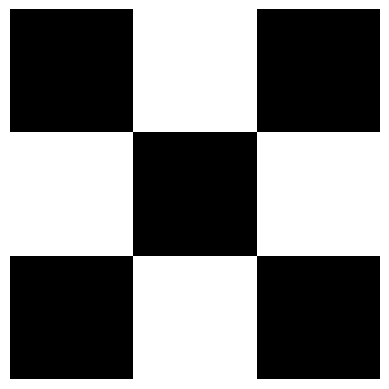

In [ ]:
# Example code to read and display an image
import cv2
import matplotlib.pyplot as plt

# Reading the image from file
# image = cv2.imread('./images/checkerboard_18x18.png', cv2.IMREAD_GRAYSCALE)
image = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/checkerboard_18x18.png', cv2.IMREAD_GRAYSCALE)



# Displaying the image using matplotlib
plt.imshow(image, cmap='gray')
plt.axis('off')  # Hide axes for a cleaner look
plt.show()

In [ ]:
print(image)

[[  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [255 255 255 255 255 255   0   0   0   0   0   0 255 255 255 255 255 255]
 [  0   0   0   0   0   0 255 255 255 255 255 255   0   0   0   0   0   0]
 [  0   0   0   0   0   0

In [ ]:
print(image.shape)

(18, 18)


In [ ]:
image[10,10]

np.uint8(0)

In [ ]:
cv2.imwrite("image.jpg", image)

True

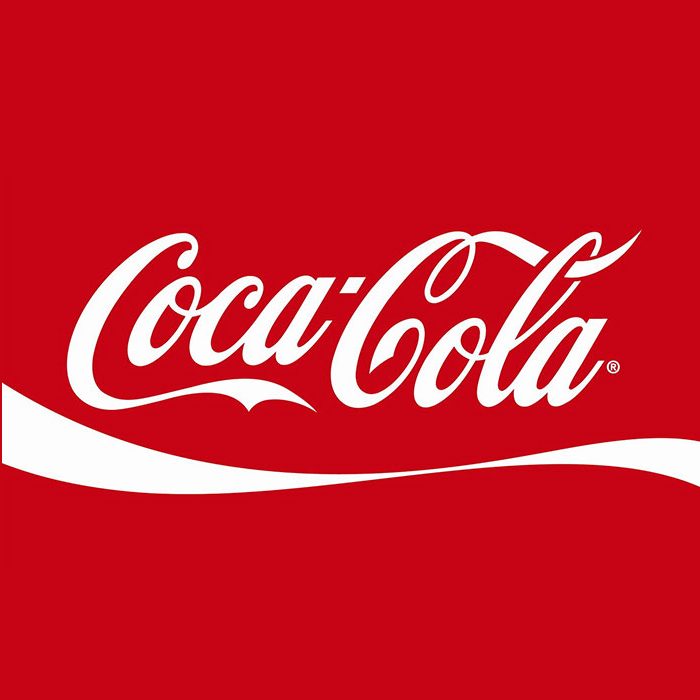

In [ ]:
from google.colab.patches import cv2_imshow

# Reading the image from file
# image = cv2.imread('./images/coca-cola-logo.png')
image = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/coca-cola-logo.png')


# Displaying the image using OpenCV
cv2_imshow(image)
cv2.waitKey(0)  # Waits for a key press to close the image window
cv2.destroyAllWindows()  # Closes the window displaying the image

# Displaying the image using matplotlib (alternative to OpenCV)
# plt.imshow(image)
# plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct color display
# plt.axis('off')  # Hide axes for a cleaner look
# plt.show()


**Key Points:**
- Images are read as arrays of pixels.
- OpenCV reads images in BGR format, while most other libraries use RGB, so conversions might be necessary.
- imshow is a simple way to display images, but for more complex visualizations, libraries like Matplotlib offer greater flexibility.


### 1.2 Color Spaces

Images can be represented in different color spaces, each emphasizing different aspects of the image data. Understanding and converting between these color spaces is fundamental in many image processing tasks. We'll explore common color spaces such as RGB (Red, Green, Blue), Grayscale, and HSV (Hue, Saturation, Value). Converting between these color spaces can be useful for different image processing tasks, such as segmentation or object detection.

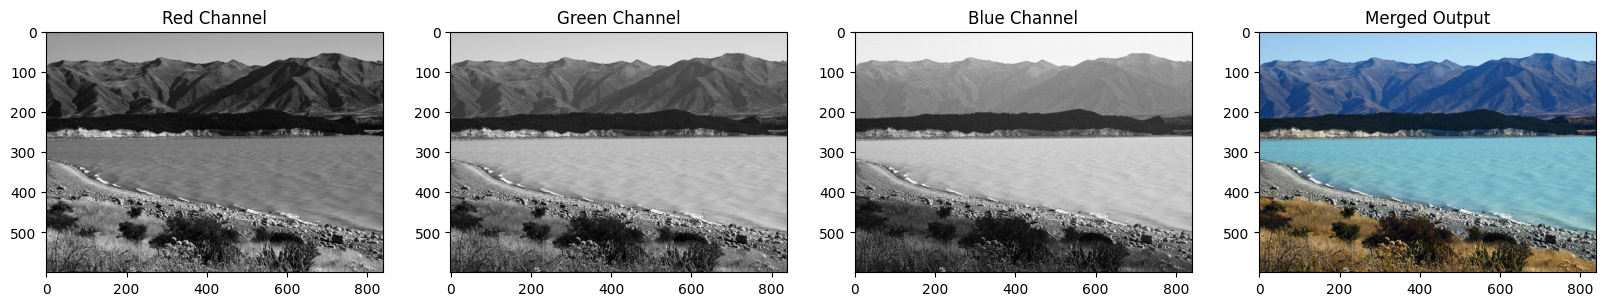

In [ ]:
# Split the image into the B,G,R components
# img_NZ_bgr = cv2.imread("./images/New_Zealand_Lake.jpg")
img_NZ_bgr = cv2.imread("/content/drive/MyDrive/CV_DAY01_Images/New_Zealand_Lake.jpg")

b, g, r = cv2.split(img_NZ_bgr)

# Merge the individual channels into a BGR image
imgMerged = cv2.merge((b, g, r))

# Show the channels
plt.figure(figsize=[20, 5])

plt.subplot(141);plt.imshow(r, cmap="gray");plt.title("Red Channel")
plt.subplot(142);plt.imshow(g, cmap="gray");plt.title("Green Channel")
plt.subplot(143);plt.imshow(b, cmap="gray");plt.title("Blue Channel")

# Show the merged output
plt.subplot(144);plt.imshow(imgMerged[:, :, ::-1]);plt.title("Merged Output")
plt.show()

In [ ]:
# img_NZ_gray = cv2.imread("./images/New_Zealand_Lake.jpg", cv2.IMREAD_GRAYSCALE)
img_NZ_gray = cv2.imread("/content/drive/MyDrive/CV_DAY01_Images/New_Zealand_Lake.jpg", cv2.IMREAD_GRAYSCALE)


In [ ]:
img_NZ_gray.shape

(600, 840)

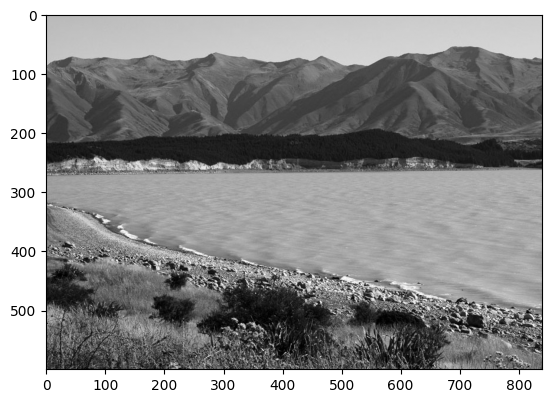

In [ ]:
plt.imshow(img_NZ_gray, cmap="gray")

In [ ]:
img_NZ_bgr[0,0,:]

array([232, 194, 146], dtype=uint8)

In [ ]:
img_NZ_bgr.shape

(600, 840, 3)

In [ ]:
img_NZ_bgr.shape

(600, 840, 3)

In [ ]:
img_NZ_bgr.shape

(600, 840, 3)

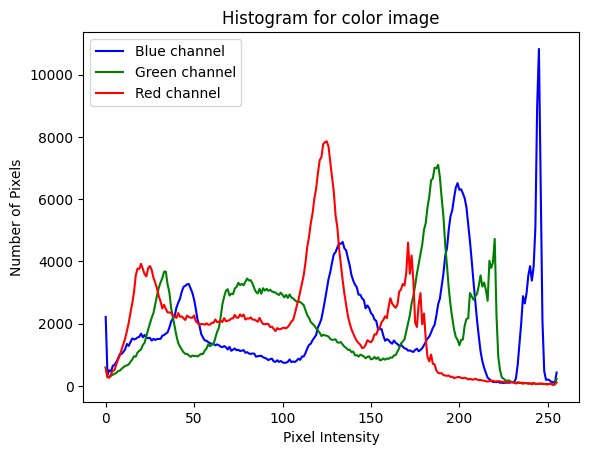

In [ ]:
# Split the image into its respective Red, Green, and Blue channels
channels = cv2.split(img_NZ_bgr)
colors = ('b', 'g', 'r')
channel_names = ('Blue', 'Green', 'Red')

# Create a plot for the histograms
plt.figure()
plt.title("Histogram for color image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

# Calculate and plot the histogram for each channel
for channel, color, name in zip(channels, colors, channel_names):
    histogram = cv2.calcHist([channel], [0], None, [256], [0, 256])
    plt.plot(histogram, color=color, label=f'{name} channel')

plt.legend()
plt.show()

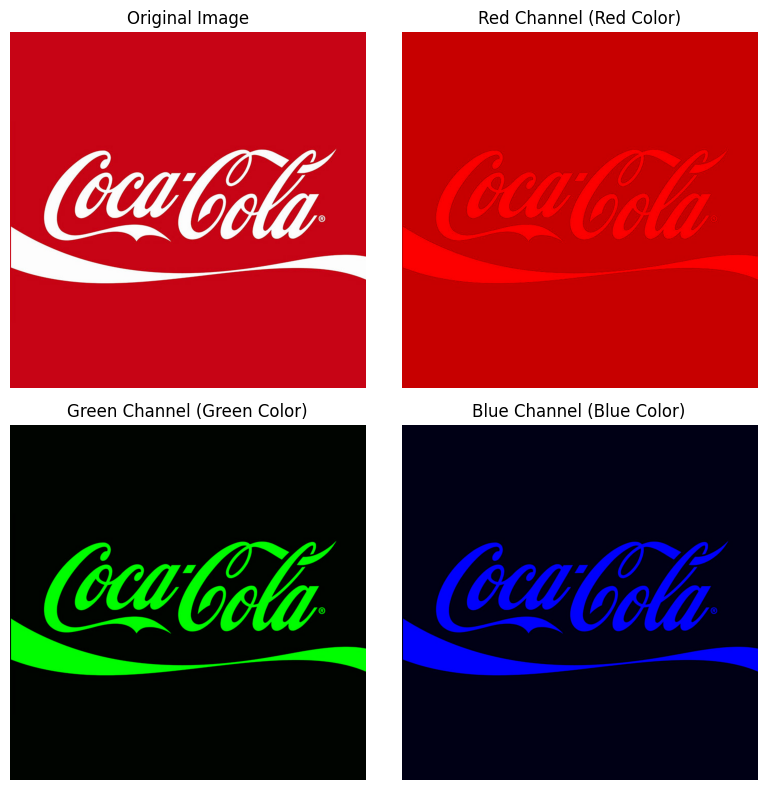

In [ ]:
import numpy as np

# Read the original image
#image = cv2.imread('./images/coca-cola-logo.png')
image = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/coca-cola-logo.png')

# Convert to RGB for displaying with matplotlib (OpenCV loads in BGR by default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Split the image into Red, Green, and Blue channels
b_channel, g_channel, r_channel = cv2.split(image)

# Create empty channels for merging
zeros = np.zeros_like(b_channel)

# Creating the Red, Green, and Blue channel images in their respective colors
red_image = cv2.merge([r_channel, zeros, zeros])    # Red channel as red
green_image = cv2.merge([zeros, g_channel, zeros])   # Green channel as green
blue_image = cv2.merge([zeros, zeros, b_channel])    # Blue channel as blue

# Displaying images
plt.figure(figsize=(8, 8))
plt.subplot(2, 2, 1); plt.imshow(image_rgb); plt.title('Original Image'); plt.axis('off')
plt.subplot(2, 2, 2); plt.imshow(red_image); plt.title('Red Channel (Red Color)'); plt.axis('off')
plt.subplot(2, 2, 3); plt.imshow(green_image); plt.title('Green Channel (Green Color)'); plt.axis('off')
plt.subplot(2, 2, 4); plt.imshow(blue_image); plt.title('Blue Channel (Blue Color)'); plt.axis('off')
plt.tight_layout()
plt.show()

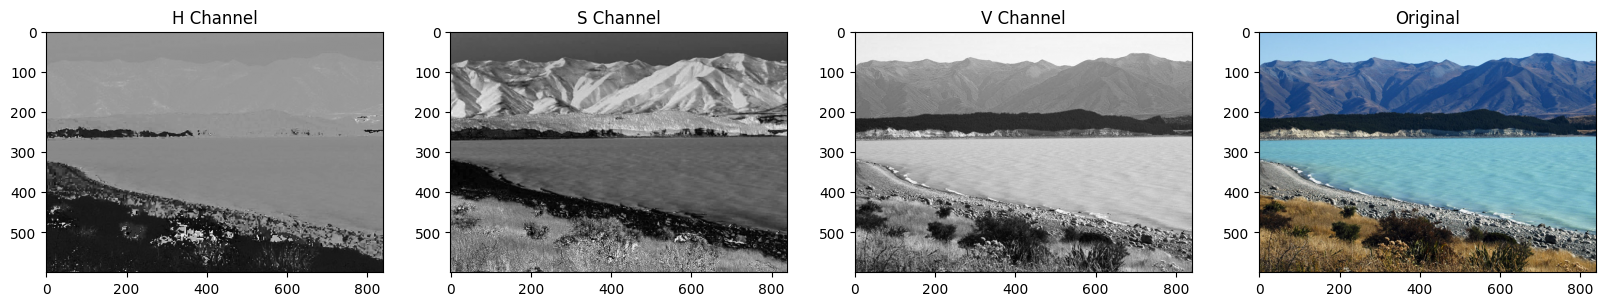

In [ ]:
# Convert to HSV color space
img_hsv = cv2.cvtColor(img_NZ_bgr, cv2.COLOR_BGR2HSV)

# Split the image into the H,S,V components
h,s,v = cv2.split(img_hsv)

# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h, cmap="gray");plt.title("H Channel");
plt.subplot(142);plt.imshow(s, cmap="gray");plt.title("S Channel");
plt.subplot(143);plt.imshow(v, cmap="gray");plt.title("V Channel");
plt.subplot(144);plt.imshow(img_NZ_bgr[:, :, ::-1]);   plt.title("Original");
plt.show()

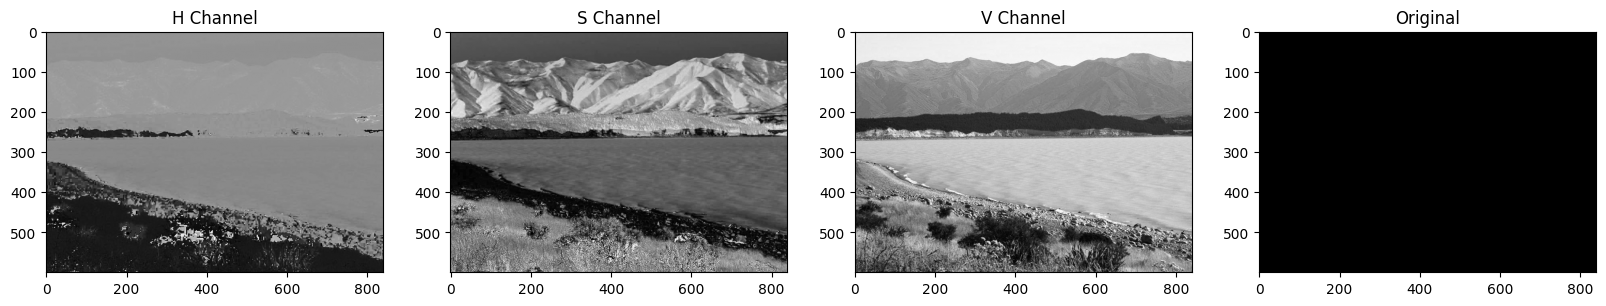

In [ ]:
# Modify the hue of the image
h_new = h + 100
v_new = v - v
img_NZ_merged = cv2.merge((h_new, s, v_new))
img_NZ_rgb = cv2.cvtColor(img_NZ_merged, cv2.COLOR_HSV2RGB)

# Show the channels
plt.figure(figsize=[20,5])
plt.subplot(141);plt.imshow(h, cmap="gray");plt.title("H Channel");
plt.subplot(142);plt.imshow(s, cmap="gray");plt.title("S Channel");
plt.subplot(143);plt.imshow(v, cmap="gray");plt.title("V Channel");
plt.subplot(144);plt.imshow(img_NZ_rgb);   plt.title("Original");
plt.show()

**Key Points:**

- RGB: Standard color space where colors are represented by their Red, Green, and Blue components.
- Grayscale: Reduces the color information to shades of gray, simplifying many image processing tasks.
- HSV: Separates the image’s color (Hue) from its intensity (Saturation and Value), which is particularly useful for tasks involving color manipulation.

## 2. Image processing fundamentals

### 2.1 Thresholding

Segmentation technique to create binary images. Binary Images have a lot of use cases in Image Processing. One of the most common use cases is that of creating masks. Image Masks allow us to process on specific parts of an image keeping the other parts intact. Image Thresholding is used to create Binary Images from grayscale images. You can use different thresholds to create different binary images from the same original image. We will apply different thresholding techniques to separate objects from the background.

**Function Syntax**

``` python
retval, dst = cv2.threshold( src, thresh, maxval, type[, dst] )
```

`dst`: The output array of the same size and type and the same number of channels as `src`.

The function has **4 required arguments**:

1. `src`: input array (multiple-channel, 8-bit or 32-bit floating point).

2. `thresh`: threshold value.

3. `maxval`: maximum value to use with the THRESH_BINARY and THRESH_BINARY_INV thresholding types.

4. `type`: thresholding type (see ThresholdTypes).


**Function Syntax**

``` python
dst = cv.adaptiveThreshold( src, maxValue, adaptiveMethod, thresholdType, blockSize, C[, dst] )
```

`dst`	Destination image of the same size and the same type as src.

The function has **6 required arguments**:
1. `src`:	Source 8-bit single-channel image.

2. `maxValue`:	Non-zero value assigned to the pixels for which the condition is satisfied

3. `adaptiveMethod`:	Adaptive thresholding algorithm to use, see AdaptiveThresholdTypes. The BORDER_REPLICATE | BORDER_ISOLATED is used to process boundaries.

4. `thresholdType:`	Thresholding type that must be either THRESH_BINARY or THRESH_BINARY_INV, see ThresholdTypes.

5. `blockSize`:	Size of a pixel neighborhood that is used to calculate a threshold value for the pixel: 3, 5, 7, and so on.

6. `C`:	Constant subtracted from the mean or weighted mean (see the details below). Normally, it is positive but may be zero or negative as well.

/tmp/ipykernel_11814/2526519748.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_image.ravel(), 256, [0, 256], color='gray')


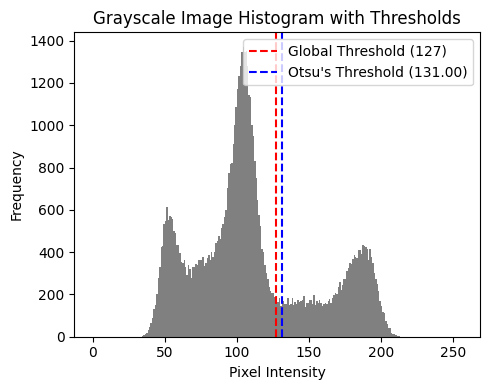

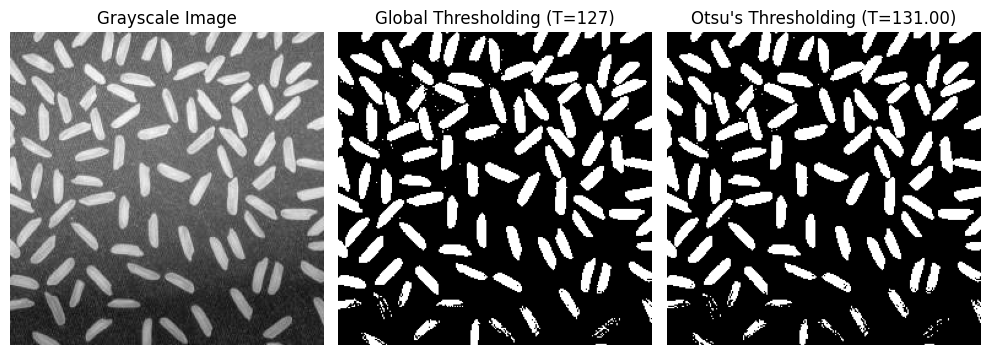

In [ ]:
# Read the image
# image = cv2.imread('./images/rice.jpg')
image = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/rice.jpg')

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply global thresholding
global_threshold_value = 127
_, global_thresh = cv2.threshold(gray_image, global_threshold_value, 255, cv2.THRESH_BINARY)

# Apply Otsu's thresholding
otsu_thresh_value, otsu_thresh = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Plot the histogram of the grayscale image (to show bimodal distribution)
plt.figure(figsize=(5, 4))
plt.hist(gray_image.ravel(), 256, [0, 256], color='gray')
plt.axvline(global_threshold_value, color='red', linestyle='--', label=f'Global Threshold ({global_threshold_value})')
plt.axvline(otsu_thresh_value, color='blue', linestyle='--', label=f"Otsu's Threshold ({otsu_thresh_value:.2f})")
plt.title("Grayscale Image Histogram with Thresholds")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Display images in a separate figure
plt.figure(figsize=(10, 6))
plt.subplot(1, 3, 1); plt.imshow(gray_image, cmap='gray'); plt.title("Grayscale Image"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(global_thresh, cmap='gray'); plt.title(f"Global Thresholding (T={global_threshold_value})"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(otsu_thresh, cmap='gray'); plt.title(f"Otsu's Thresholding (T={otsu_thresh_value:.2f})"); plt.axis('off')
plt.tight_layout()
plt.show()

**Application: Sheet Music Reader**

Suppose you wanted to build an application that could read (decode) sheet music. This is similar to
Optical Character Recognigition (OCR) for text documents where the goal is to recognize text characters. In either application, one of the first steps in the processing pipeline is to isolate the important information in the image of a document (separating it from the background). This task can be accomplished with thresholding
techniques. Let's take a look at an example.

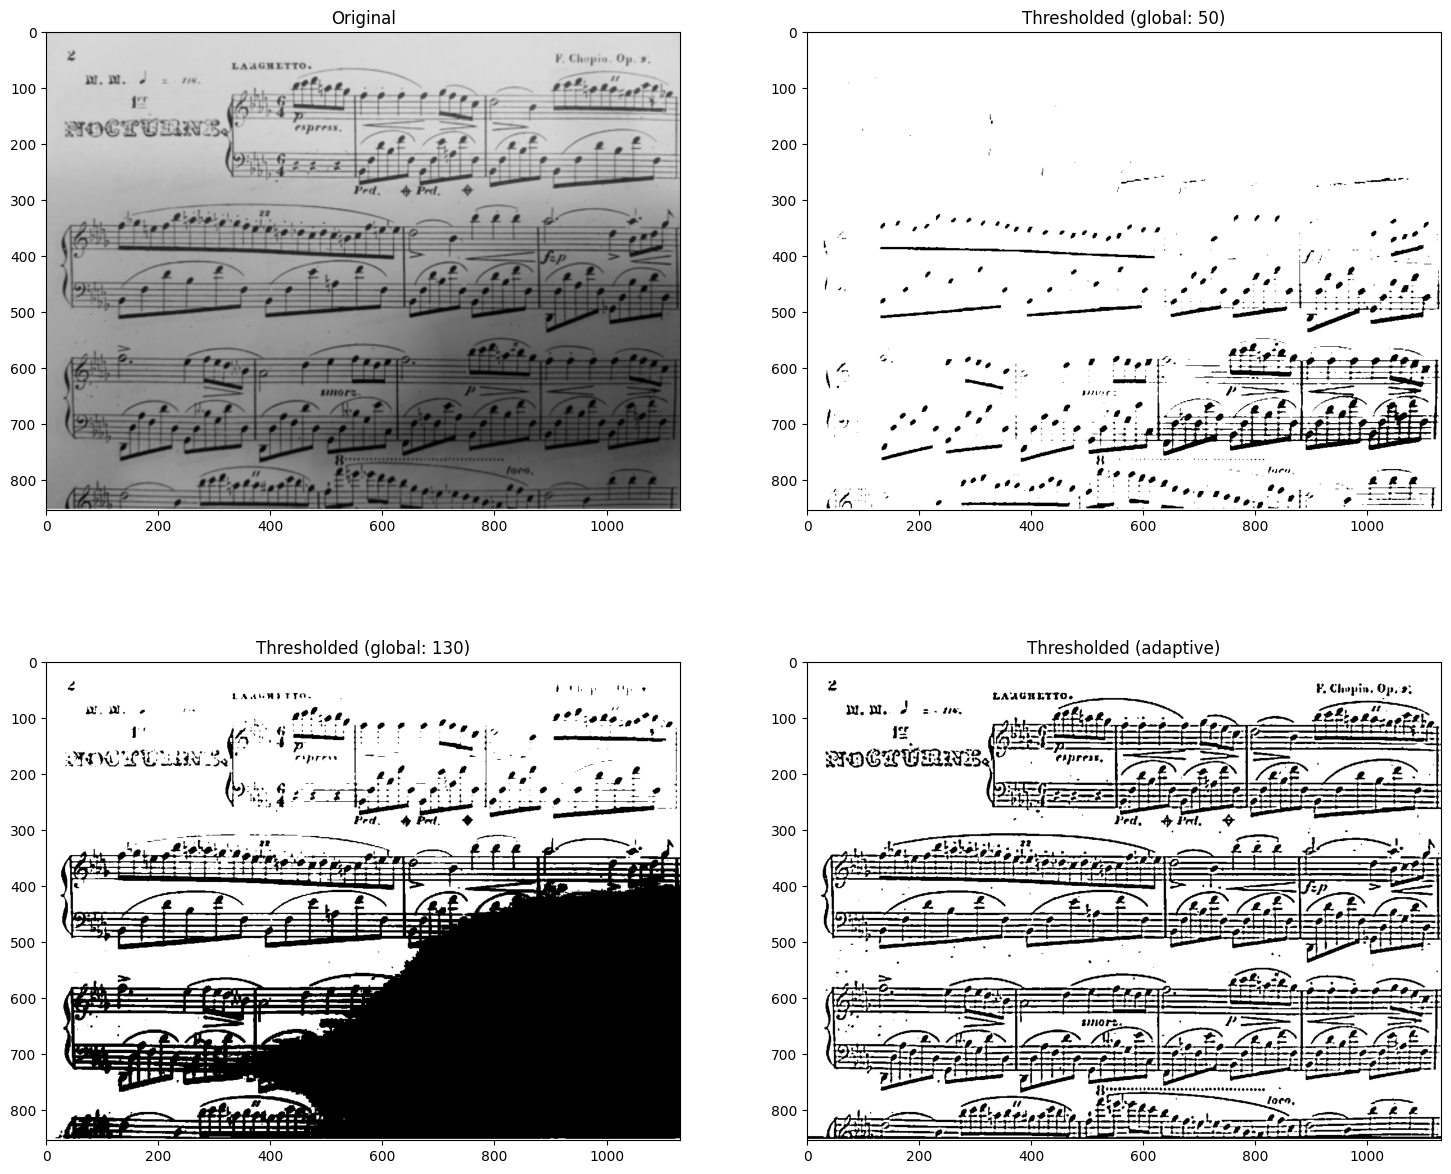

In [ ]:
# Read the original image
# img_read = cv2.imread("./images/Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)
img_read = cv2.imread("/content/drive/MyDrive/CV_DAY01_Images/Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)
# Perform global thresholding
retval, img_thresh_gbl_1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)

# Perform global thresholding
retval, img_thresh_gbl_2 = cv2.threshold(img_read, 130, 255, cv2.THRESH_BINARY)

# Perform adaptive thresholding
img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

# Show the images
plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_read,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_gbl_1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_thresh_gbl_2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_thresh_adp,  cmap="gray");  plt.title("Thresholded (adaptive)");

**Key Points:**
- Thresholding is crucial in many computer vision tasks where we need to separate objects from their backgrounds.
- The threshold value determines how aggressive the segmentation is—this value can be tuned based on the image characteristics.

### 2.2 Edge Detection
Edge detection is a crucial technique in computer vision and image processing. It involves identifying points in a digital image where the brightness changes sharply or, more formally, has discontinuities. These points typically represent object boundaries, and edge detection is used in various applications, such as image segmentation, object detection, and recognition.

In [ ]:
# Read the original image
# img = cv2.imread('./images/tiger.jpg')
img = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/tiger.jpg')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur the image for better edge detection
img_blur = cv2.GaussianBlur(gray,(3,3), 0)

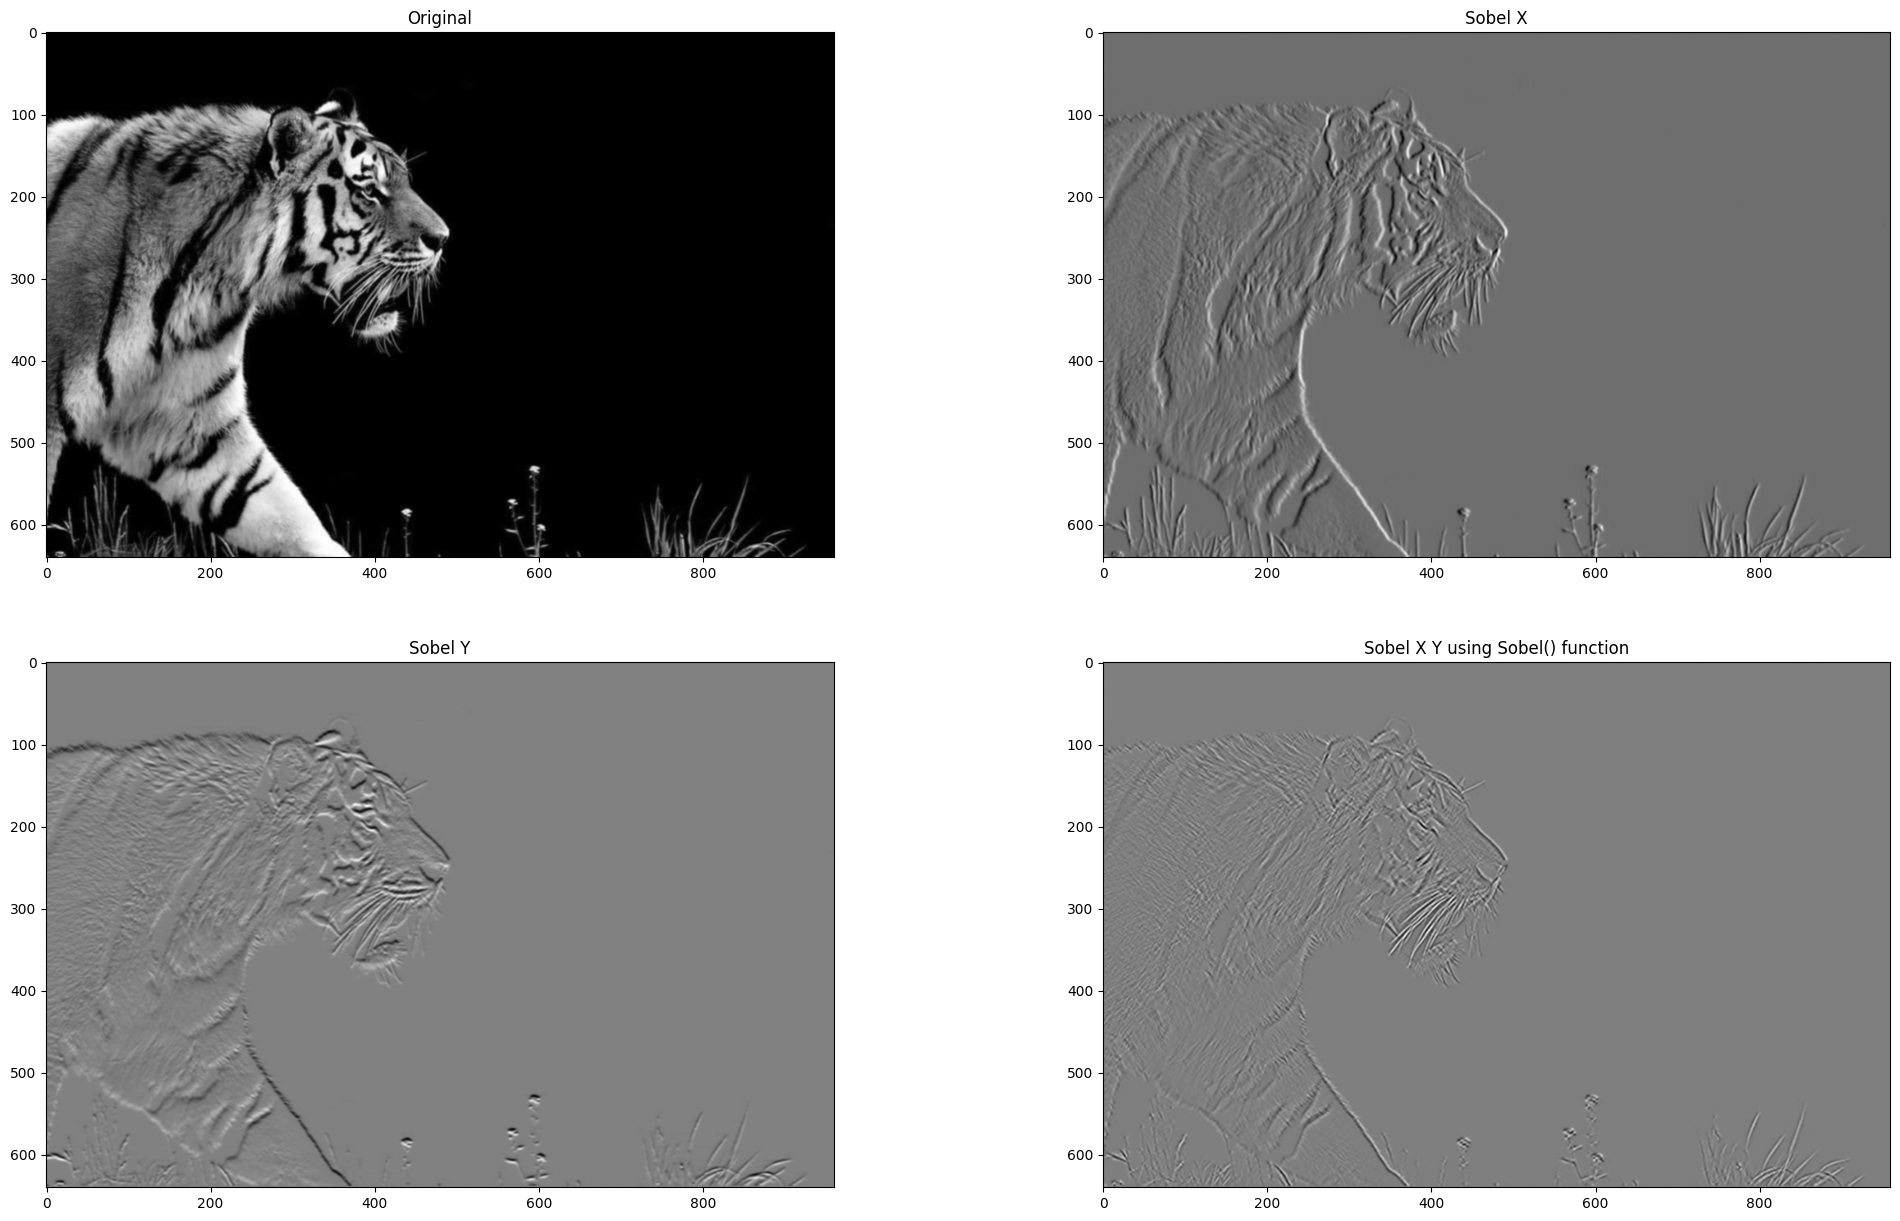

In [ ]:
# Sobel Edge Detection
sobelx = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis
sobely = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis
sobelxy = cv2.Sobel(src=img_blur, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection

# Show the images
plt.figure(figsize=[25,15])
plt.subplot(221); plt.imshow(img_blur, cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(sobelx, cmap="binary");  plt.title("Sobel X");
plt.subplot(223); plt.imshow(sobely, cmap="binary");  plt.title("Sobel Y");
plt.subplot(224); plt.imshow(sobelxy, cmap="binary");  plt.title("Sobel X Y using Sobel() function");

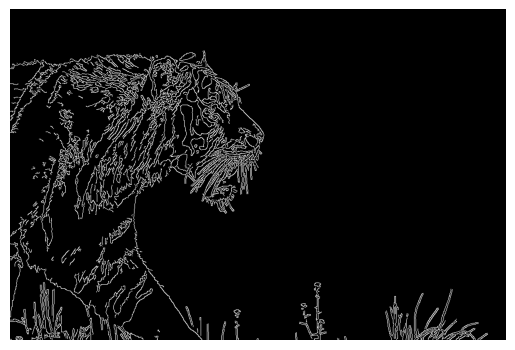

In [ ]:
# Canny Edge Detection
edges = cv2.Canny(image=img_blur, threshold1=100, threshold2=200)

plt.imshow(edges, cmap='gray')
plt.axis('off')  # Hide axes for a cleaner look
plt.show()

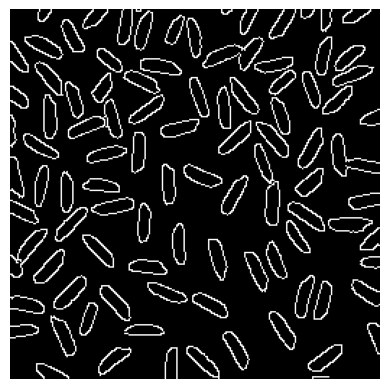

In [ ]:
# Read the image
# image = cv2.imread('./images/rice.jpg')
image = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/rice.jpg')

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur the image for better edge detection
img_blur = cv2.GaussianBlur(gray_image,(3,3), 0)

# Canny Edge Detection
edges = cv2.Canny(image=img_blur, threshold1=100, threshold2=200)

plt.imshow(edges, cmap='gray')
plt.axis('off')  # Hide axes for a cleaner look
plt.show()

**Key Points:**
- Edge detection simplifies the image by highlighting the contours of objects, which are crucial for tasks like shape analysis and object recognition.
- Canny edge detection is particularly robust, as it uses both gradient magnitude and direction, along with non-maximum suppression, to detect true edges.

### 2.3 Blob detection

**What is Blob Detection?**
- **Blob detection** refers to identifying regions in an image that differ in properties such as brightness or color compared to surrounding regions.
- It is used to detect objects in an image, especially when the object has uniform characteristics (like a spot or blob).

**How Blob Detection Works**
- Blob detection typically looks for **connected regions** in an image that meet certain conditions.
- The process uses filters to select blobs based on criteria like size, circularity, convexity, and inertia ratio.

**Key Parameters in OpenCV Blob Detection:**
- **Thresholding**: Used to differentiate blobs based on pixel intensity.
- **MinArea/MaxArea**: Filters blobs based on size.
- **Circularity**: Detects blobs based on how close the shape is to a perfect circle.
- **Convexity**: Measures the level of convexity for a blob (a convex shape has no inward dents).
- **Inertia Ratio**: Determines the blob's shape elongation (helps in detecting elongated blobs).

**Steps for Blob Detection in OpenCV:**
1. Convert the image to grayscale.
2. Apply blob detection using `SimpleBlobDetector` in OpenCV.
3. Set the parameters to filter blobs based on desired characteristics (size, circularity, etc.).

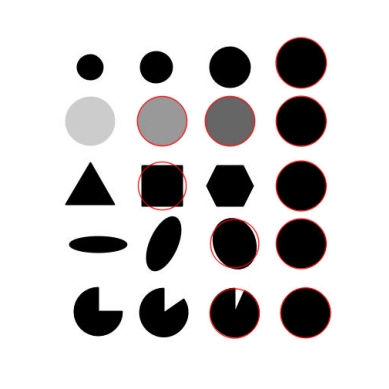

In [ ]:
import numpy as np

# Read image
# im = cv2.imread("./images/blob.jpg", cv2.IMREAD_GRAYSCALE)
im = cv2.imread("/content/drive/MyDrive/CV_DAY01_Images/blob.jpg", cv2.IMREAD_GRAYSCALE)

# Setup SimpleBlobDetector parameters.
params = cv2.SimpleBlobDetector_Params()

# Change thresholds
params.minThreshold = 10
params.maxThreshold = 200


# Filter by Area.
params.filterByArea = True
params.minArea = 3000

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.1

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.87

# Filter by Inertia
params.filterByInertia = True
params.minInertiaRatio = 0.01

# Create a detector with the parameters
ver = (cv2.__version__).split('.')
if int(ver[0]) < 3 :
	detector = cv2.SimpleBlobDetector(params)
else :
	detector = cv2.SimpleBlobDetector_create(params)


# Detect blobs.
keypoints = detector.detect(im)

# Draw detected blobs as red circles.
# cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS ensures
# the size of the circle corresponds to the size of blob

im_with_keypoints = cv2.drawKeypoints(im, keypoints, np.array([]), (0,0,255), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Show blobs
plt.imshow(cv2.cvtColor(im_with_keypoints, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct color display
plt.axis('off')  # Hide axes for a cleaner look
plt.show()


**Key Points:**
- Blob Detection: Finds regions (blobs) with similar characteristics like size and shape, useful for object detection.
- Parameter Tuning: Adjusts area, circularity, and convexity to filter blobs based on desired properties.

## 3. Image pre-processing in Deep Learning

Image pre-processing is a crucial step in preparing raw images for computer vision tasks. Common techniques include resizing, normalization, and augmentation, which help improve the performance of machine learning models and other vision algorithms.

#### 3.1 Normalization and Standardization

Normalization rescales the pixel values to a standard range, typically [0, 1]. Standardization, on the other hand, adjusts the pixel values by removing the mean and scaling them by the standard deviation, resulting in a mean of 0 and a standard deviation of 1.

Mean of the input image: [0.45988557 0.45332977 0.46352522]
Standard deviation of the input image: [0.29957468 0.26399318 0.23529656]
Standard deviation after standardization: [1. 1. 1.]


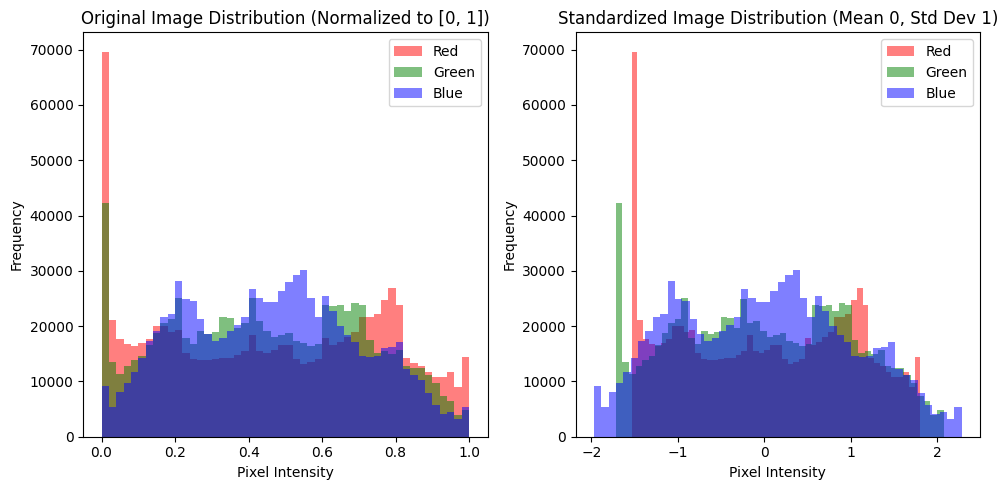

In [ ]:

# Load the image and normalize to [0, 1]
# image = cv2.imread('./images/bus.jpg')
image = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/bus.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image / 255.0  # Normalize pixel values to [0, 1]

# Calculate mean and standard deviation of the input image
image_mean = np.mean(image, axis=(0, 1))
image_std = np.std(image, axis=(0, 1))

# Print the calculated mean and standard deviation of the image
print(f"Mean of the input image: {image_mean}")
print(f"Standard deviation of the input image: {image_std}")

# Flatten the image channels for histogram plotting
flattened_image = image.reshape(-1, 3)

# Plot histogram of the original image
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(flattened_image[:, 0], bins=50, color='r', alpha=0.5, label='Red')
plt.hist(flattened_image[:, 1], bins=50, color='g', alpha=0.5, label='Green')
plt.hist(flattened_image[:, 2], bins=50, color='b', alpha=0.5, label='Blue')
plt.title('Original Image Distribution (Normalized to [0, 1])')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()

# Function to normalize (standardize) using the input image's mean and std
def standardize(image, mean, std):
    return (image - mean) / std

# Apply standardization using the image's own mean and std deviation
standardized_image = standardize(image, image_mean, image_std)

# Calculate standard deviation after standardization
standardized_std = np.std(standardized_image, axis=(0, 1))
print(f"Standard deviation after standardization: {standardized_std}")

# Flatten the standardized image for histogram plotting
flattened_standardized = standardized_image.reshape(-1, 3)

# Plot histogram of the standardized image
plt.subplot(1, 2, 2)
plt.hist(flattened_standardized[:, 0], bins=50, color='r', alpha=0.5, label='Red')
plt.hist(flattened_standardized[:, 1], bins=50, color='g', alpha=0.5, label='Green')
plt.hist(flattened_standardized[:, 2], bins=50, color='b', alpha=0.5, label='Blue')
plt.title('Standardized Image Distribution (Mean 0, Std Dev 1)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

#### 3.2 Letterbox Resizing

**Why Resizing is Important for Model Training**
- Deep learning models require input images to be of a consistent size for efficient processing.
- Resizing ensures uniformity across all input images.

**Issues with Regular Resizing**
- **Aspect ratio is not maintained**, which means:
  - Images get stretched or squished.
  - Objects within the images may appear distorted, which can affect the model's understanding of object shapes and features.

**What is Letterbox Resizing?**
- **Letterbox resizing** solves the issue of distorted images by:
  - Resizing the image while maintaining the original aspect ratio.
  - Adding padding (typically black or gray) to the remaining space in the target dimensions.
  - Ensuring that the objects in the image retain their correct shape without stretching.

Image dimensions : (1080, 810, 3)


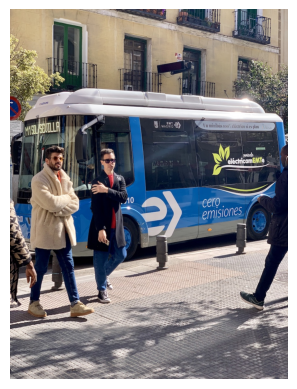

In [ ]:
# Reading the image from file
# bus = cv2.imread('./images/bus.jpg', 1)
bus = cv2.imread('/content/drive/MyDrive/CV_DAY01_Images/bus.jpg', 1)
print(f'Image dimensions : {bus.shape}')

# Displaying the image using matplotlib (alternative to OpenCV)
plt.imshow(cv2.cvtColor(bus, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct color display
plt.axis('off')  # Hide axes for a cleaner look
plt.show()

Image dimensions : (640, 640, 3)


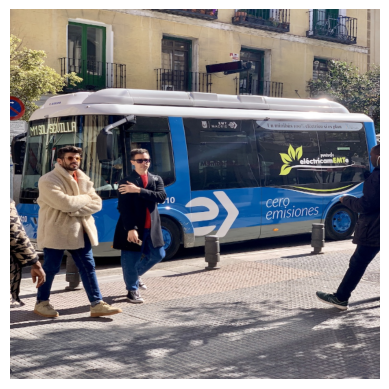

In [ ]:
bus_resize = cv2.resize(bus, (640,640))

print(f'Image dimensions : {bus_resize.shape}')

# Displaying the image using matplotlib (alternative to OpenCV)
plt.imshow(cv2.cvtColor(bus_resize, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct color display
plt.axis('off')  # Hide axes for a cleaner look
plt.show()


In [ ]:
def letterbox(im, new_shape=(640, 640), color=(114, 114, 114), auto=True, scaleFill=False, scaleup=True, stride=32):
    """Resizes and pads image to new_shape with stride-multiple constraints, returns resized image, ratio, padding."""
    shape = im.shape[:2]  # current shape [height, width]
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)

    # Scale ratio (new / old)
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    if not scaleup:  # only scale down, do not scale up (for better val mAP)
        r = min(r, 1.0)

    # Compute padding
    ratio = r, r  # width, height ratios
    new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
    dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]  # wh padding
    if auto:  # minimum rectangle
        dw, dh = np.mod(dw, stride), np.mod(dh, stride)  # wh padding
    elif scaleFill:  # stretch
        dw, dh = 0.0, 0.0
        new_unpad = (new_shape[1], new_shape[0])
        ratio = new_shape[1] / shape[1], new_shape[0] / shape[0]  # width, height ratios

    dw /= 2  # divide padding into 2 sides
    dh /= 2

    if shape[::-1] != new_unpad:  # resize
        im = cv2.resize(im, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    im = cv2.copyMakeBorder(im, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)  # add border
    return im, ratio, (dw, dh)

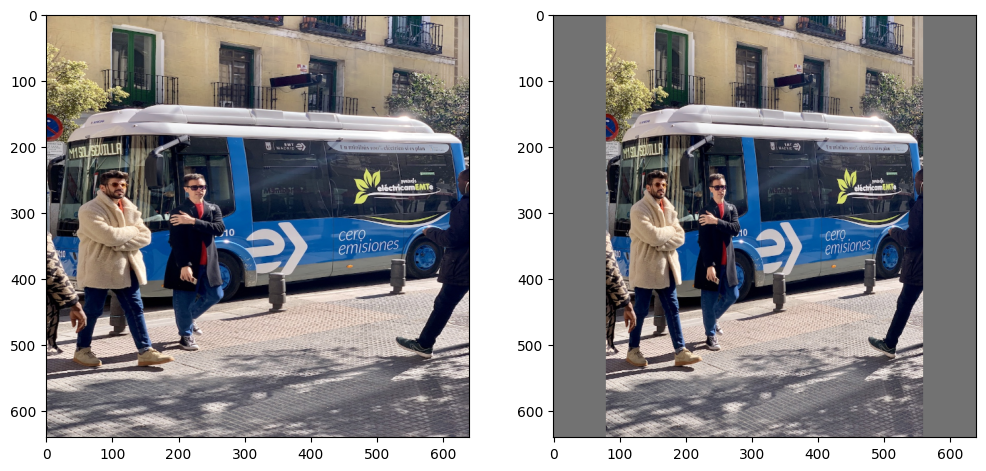

In [ ]:
bus_letter, ratio, (dw, dh) = letterbox(bus, new_shape=(640, 640), auto=False, scaleFill=False)

# Displaying the image using matplotlib (alternative to OpenCV)
plt.figure(figsize=[12,10])
plt.subplot(121);plt.imshow(cv2.cvtColor(bus_resize, cv2.COLOR_BGR2RGB))
plt.subplot(122);plt.imshow(cv2.cvtColor(bus_letter, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct color display
plt.show()